<a href="https://colab.research.google.com/github/JFish72/CSC-349-Machine-Learning-/blob/main/Midterm/air_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task One (Attached with Task 8):**

**Task Two:**

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('AirQualityUCI.csv',  sep = ';', decimal = ',')

**Task Three:**

In [ ]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


In [ ]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,NaN,NaN
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,NaN,NaN
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,NaN,NaN
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,NaN,NaN
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,NaN,NaN


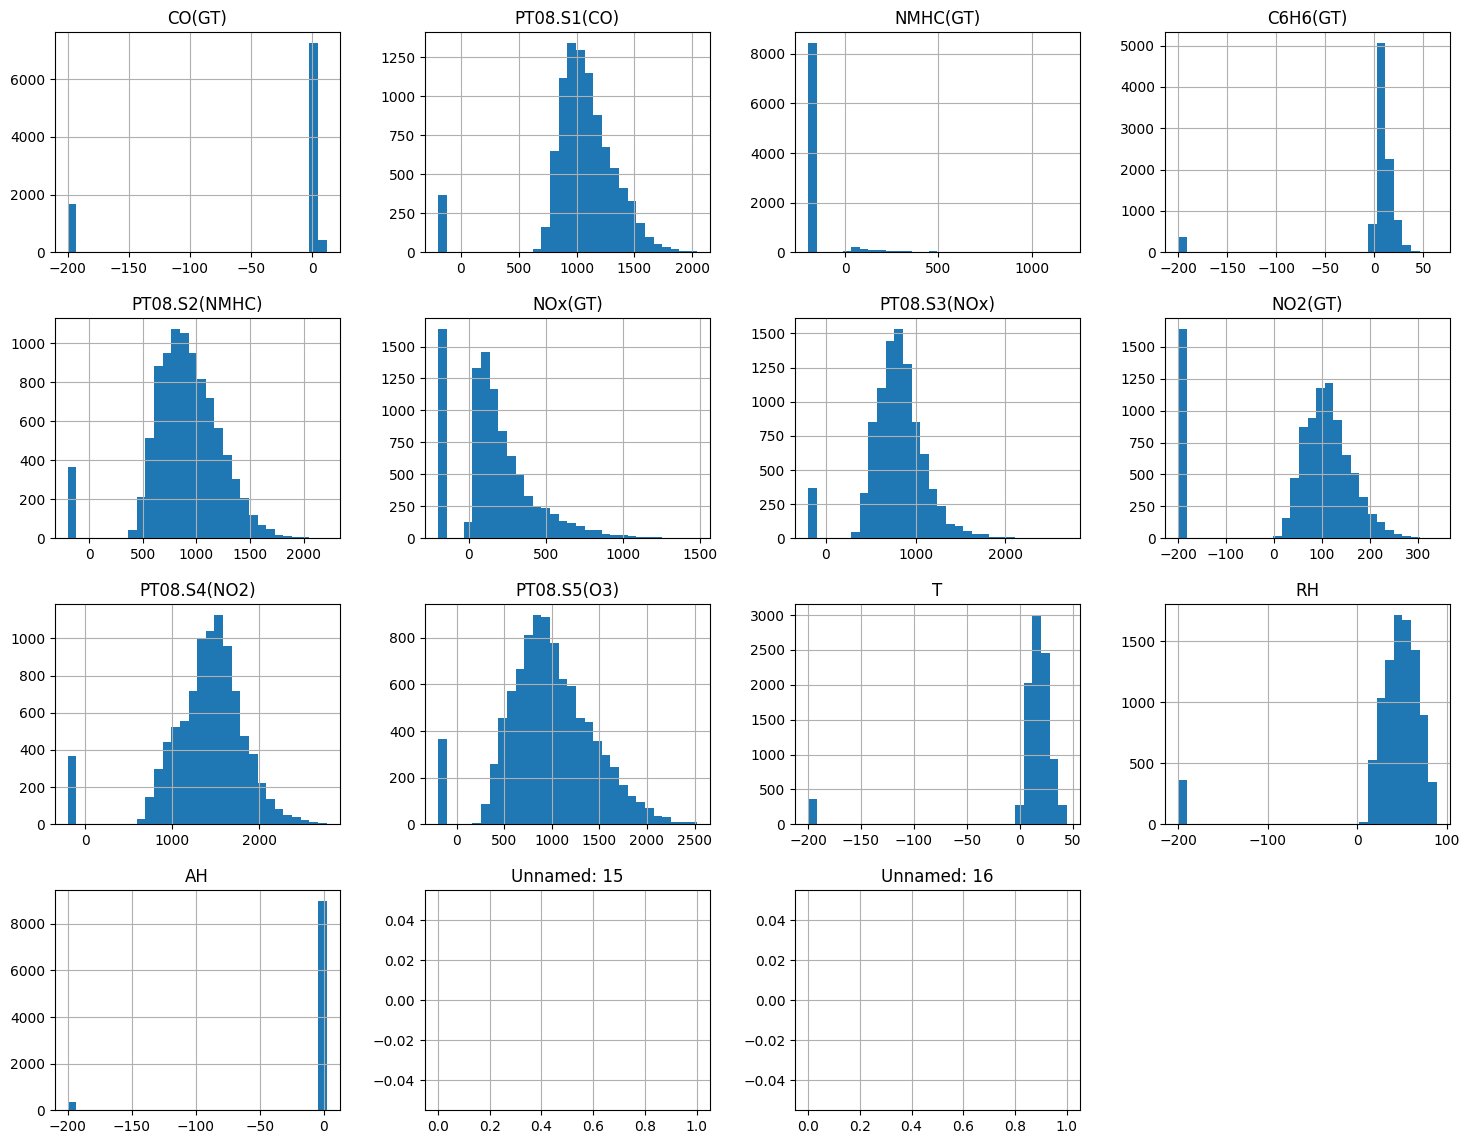

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

numerical = df.select_dtypes(include = np.number).columns
df[numerical].hist(figsize = (18, 14), bins=30)

plt.show()

**Task Four:**

In [ ]:
from sklearn.impute import SimpleImputer

df = df.dropna(how = 'all', axis = 1)
df = df.dropna(how = 'all', axis = 0)

df = df.replace(-200, np.nan)

numerical = df.select_dtypes(include=np.number).columns.tolist()

imputer = SimpleImputer(strategy='median')

imputed_data = imputer.fit_transform(df[numerical])

imputed_df = pd.DataFrame(imputed_data, columns = numerical)

df[numerical] = imputed_df

df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


**Task Five:**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numerical = df.select_dtypes(include=np.number).columns.tolist()

categorical = df.select_dtypes(exclude=np.number).columns.tolist()

numerical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('numerical', numerical_pipeline, numerical), ('categorical', categorical_pipeline, categorical)])

pipeline = Pipeline([('preprocessor', preprocessor)])

preprocessed_data = pipeline.fit_transform(df)

pipeline



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CO(GT)', 'PT08.S1(CO)',
                                                   'NMHC(GT)', 'C6H6(GT)',
                                                   'PT08.S2(NMHC)', 'NOx(GT)',
                                                   'PT08.S3(NOx)', 'NO2(GT)',
                                                   'PT08.S4(NO2)',
                                                   'PT08.S5(O3)', 'T', 'RH',
                                                   'AH']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Date', 'Time'])]))])

**Task Six:**

In [ ]:
from sklearn.model_selection import train_test_split

classification_df = df.copy()

classification_df = classification_df.dropna(subset = ['CO(GT)'])

classification_df["CO_Category"] = pd.qcut(classification_df["CO(GT)"], q = 3, labels = ["Low", "Medium", "High"])

X = classification_df.drop(columns = ["CO(GT)", "CO_Category"])
y = classification_df["CO_Category"]

numerical_features = X.select_dtypes(include = [np.number]).columns

categorical_features = X.select_dtypes(exclude = [np.number]).columns

numerical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('numerical', numerical_pipeline, numerical_features),
 ('categorical', categorical_pipeline, categorical_features)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

**Logistic Regression:**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)
import time

logistic_pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter = 2000))])

start_time = time.time()

logistic_pipeline.fit(X_train, y_train)

logistic_time = time.time() - start_time

logistic_predictions = logistic_pipeline.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_predictions)

logistic_confusion_matrix = confusion_matrix(y_test, logistic_predictions)

logistic_classification_report = classification_report(y_test, logistic_predictions)

print("Logistic Regression Model:")
print("Regression Accuracy:", logistic_accuracy)
print("Training Time:", logistic_time)
print("Confusion Matrix:\n", logistic_confusion_matrix)
print("Classification Report:\n", logistic_classification_report)



Logistic Regression Model:
Regression Accuracy: 0.8691239316239316
Training Time: 0.4826195240020752
Confusion Matrix:
 [[563  10  49]
 [  3 570  62]
 [ 39  82 494]]
Classification Report:
               precision    recall  f1-score   support

        High       0.93      0.91      0.92       622
         Low       0.86      0.90      0.88       635
      Medium       0.82      0.80      0.81       615

    accuracy                           0.87      1872
   macro avg       0.87      0.87      0.87      1872
weighted avg       0.87      0.87      0.87      1872



**SGDClassifier:**

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_pipeline = Pipeline([('preprocessor', preprocessor),
 ('classifier', SGDClassifier(loss= "log_loss", penalty = "l2", alpha = 0.0001, max_iter = 2000, tol = 1e-3, random_state = 42))])

start_time = time.time()

sgd_pipeline.fit(X_train, y_train)

sgd_time = time.time() - start_time

sgd_predictions = sgd_pipeline.predict(X_test)

sgd_accuracy = accuracy_score(y_test, sgd_predictions)

sgd_confusion_matrix = confusion_matrix(y_test, sgd_predictions)

sgd_classification_report = classification_report(y_test, sgd_predictions)

print("SGDClassifier Model:")
print("Regression Accuracy:", sgd_accuracy)
print("Training Time:", sgd_time)
print("Confusion Matrix:\n", sgd_confusion_matrix)
print("Classification Report:\n", sgd_classification_report)

SGDClassifier Model:
Regression Accuracy: 0.8482905982905983
Training Time: 0.48011088371276855
Confusion Matrix:
 [[575  13  34]
 [  5 589  41]
 [ 66 125 424]]
Classification Report:
               precision    recall  f1-score   support

        High       0.89      0.92      0.91       622
         Low       0.81      0.93      0.86       635
      Medium       0.85      0.69      0.76       615

    accuracy                           0.85      1872
   macro avg       0.85      0.85      0.84      1872
weighted avg       0.85      0.85      0.84      1872



**Task Seven:**

In [ ]:
regression_df = df.copy()

regression_df = regression_df.dropna(subset = ['CO(GT)'])

X = regression_df.drop(columns = ["CO(GT)"])
y = regression_df["CO(GT)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

numerical_reg = X.select_dtypes(include = [np.number]).columns.tolist()

categorical_reg = X.select_dtypes(exclude = [np.number]).columns.tolist()

numerical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('numerical', numerical_pipeline, numerical_reg),
 ('categorical', categorical_pipeline, categorical_reg)])

**Linear Regression:**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

linear_pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', LinearRegression())])

linear_pipeline.fit(X_train, y_train)

linear_predictions = linear_pipeline.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_mse = mean_squared_error(y_test, linear_predictions)

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Model:")
print("Mean Absolute Error:", linear_mae)
print("Mean Squared Error:", linear_mse)
print("R-squared:", linear_r2)


Linear Regression Model:
Mean Absolute Error: 0.3094526824749309
Mean Squared Error: 0.20566624659818875
R-squared: 0.8903459918633712


**Ridge Regression:**

In [ ]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', Ridge(alpha = 1.0))])

ridge_pipeline.fit(X_train, y_train)

ridge_predictions = ridge_pipeline.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_predictions)

ridge_mse = mean_squared_error(y_test, ridge_predictions)

ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression Model:")
print("Mean Absolute Error:", ridge_mae)
print("Mean Squared Error:", ridge_mse)
print("R-squared:", ridge_r2)

Ridge Regression Model:
Mean Absolute Error: 0.30801156270288477
Mean Squared Error: 0.20412756575883825
R-squared: 0.8911663623620241


**Lasso Regression:**

In [ ]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', Lasso(alpha = 1.0, max_iter = 10000))])

lasso_pipeline.fit(X_train, y_train)

lasso_predictions = lasso_pipeline.predict(X_test)

lasso_mae = mean_absolute_error(y_test, lasso_predictions)

lasso_mse = mean_squared_error(y_test, lasso_predictions)

lasso_r2 = r2_score(y_test, lasso_predictions)

print("Lasso Regression Model:")
print("Mean Absolute Error:", lasso_mae)
print("Mean Squared Error:", lasso_mse)
print("R-squared:", lasso_r2)

Lasso Regression Model:
Mean Absolute Error: 0.9437745832319479
Mean Squared Error: 1.752819448703135
R-squared: 0.06545832741507585


**Regularization Analysis:**



In [ ]:
alpha_values = [0.01, 0.1, 1, 10, 100]

for alpha in alpha_values:
  ridge = Ridge(alpha = alpha)
  lasso = Lasso(alpha = alpha, max_iter = 20000)

  ridge_pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', ridge)])
  lasso_pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', lasso)])

  ridge_pipeline.fit(X_train, y_train)
  lasso_pipeline.fit(X_train, y_train)

  print("Alpha:", alpha)
  print("Ridge R^2", ridge_pipeline.score(X_test, y_test))
  print("Lasso R^2", lasso_pipeline.score(X_test, y_test))
  print("Lasso Zero Coefficants:", np.sum(lasso.coef_ == 0))

Alpha: 0.01
Ridge R^2 0.8904738177776004
Lasso R^2 0.8374231768674383
Lasso Zero Coefficants: 413
Alpha: 0.1
Ridge R^2 0.8905519821923217
Lasso R^2 0.8032389536793918
Lasso Zero Coefficants: 421
Alpha: 1
Ridge R^2 0.8911663623620241
Lasso R^2 0.06545832741507585
Lasso Zero Coefficants: 426
Alpha: 10
Ridge R^2 0.889054021807103
Lasso R^2 -8.516797818636235e-05
Lasso Zero Coefficants: 427
Alpha: 100
Ridge R^2 0.8638224840340146
Lasso R^2 -8.516797818636235e-05
Lasso Zero Coefficants: 427


**Task Eight:**

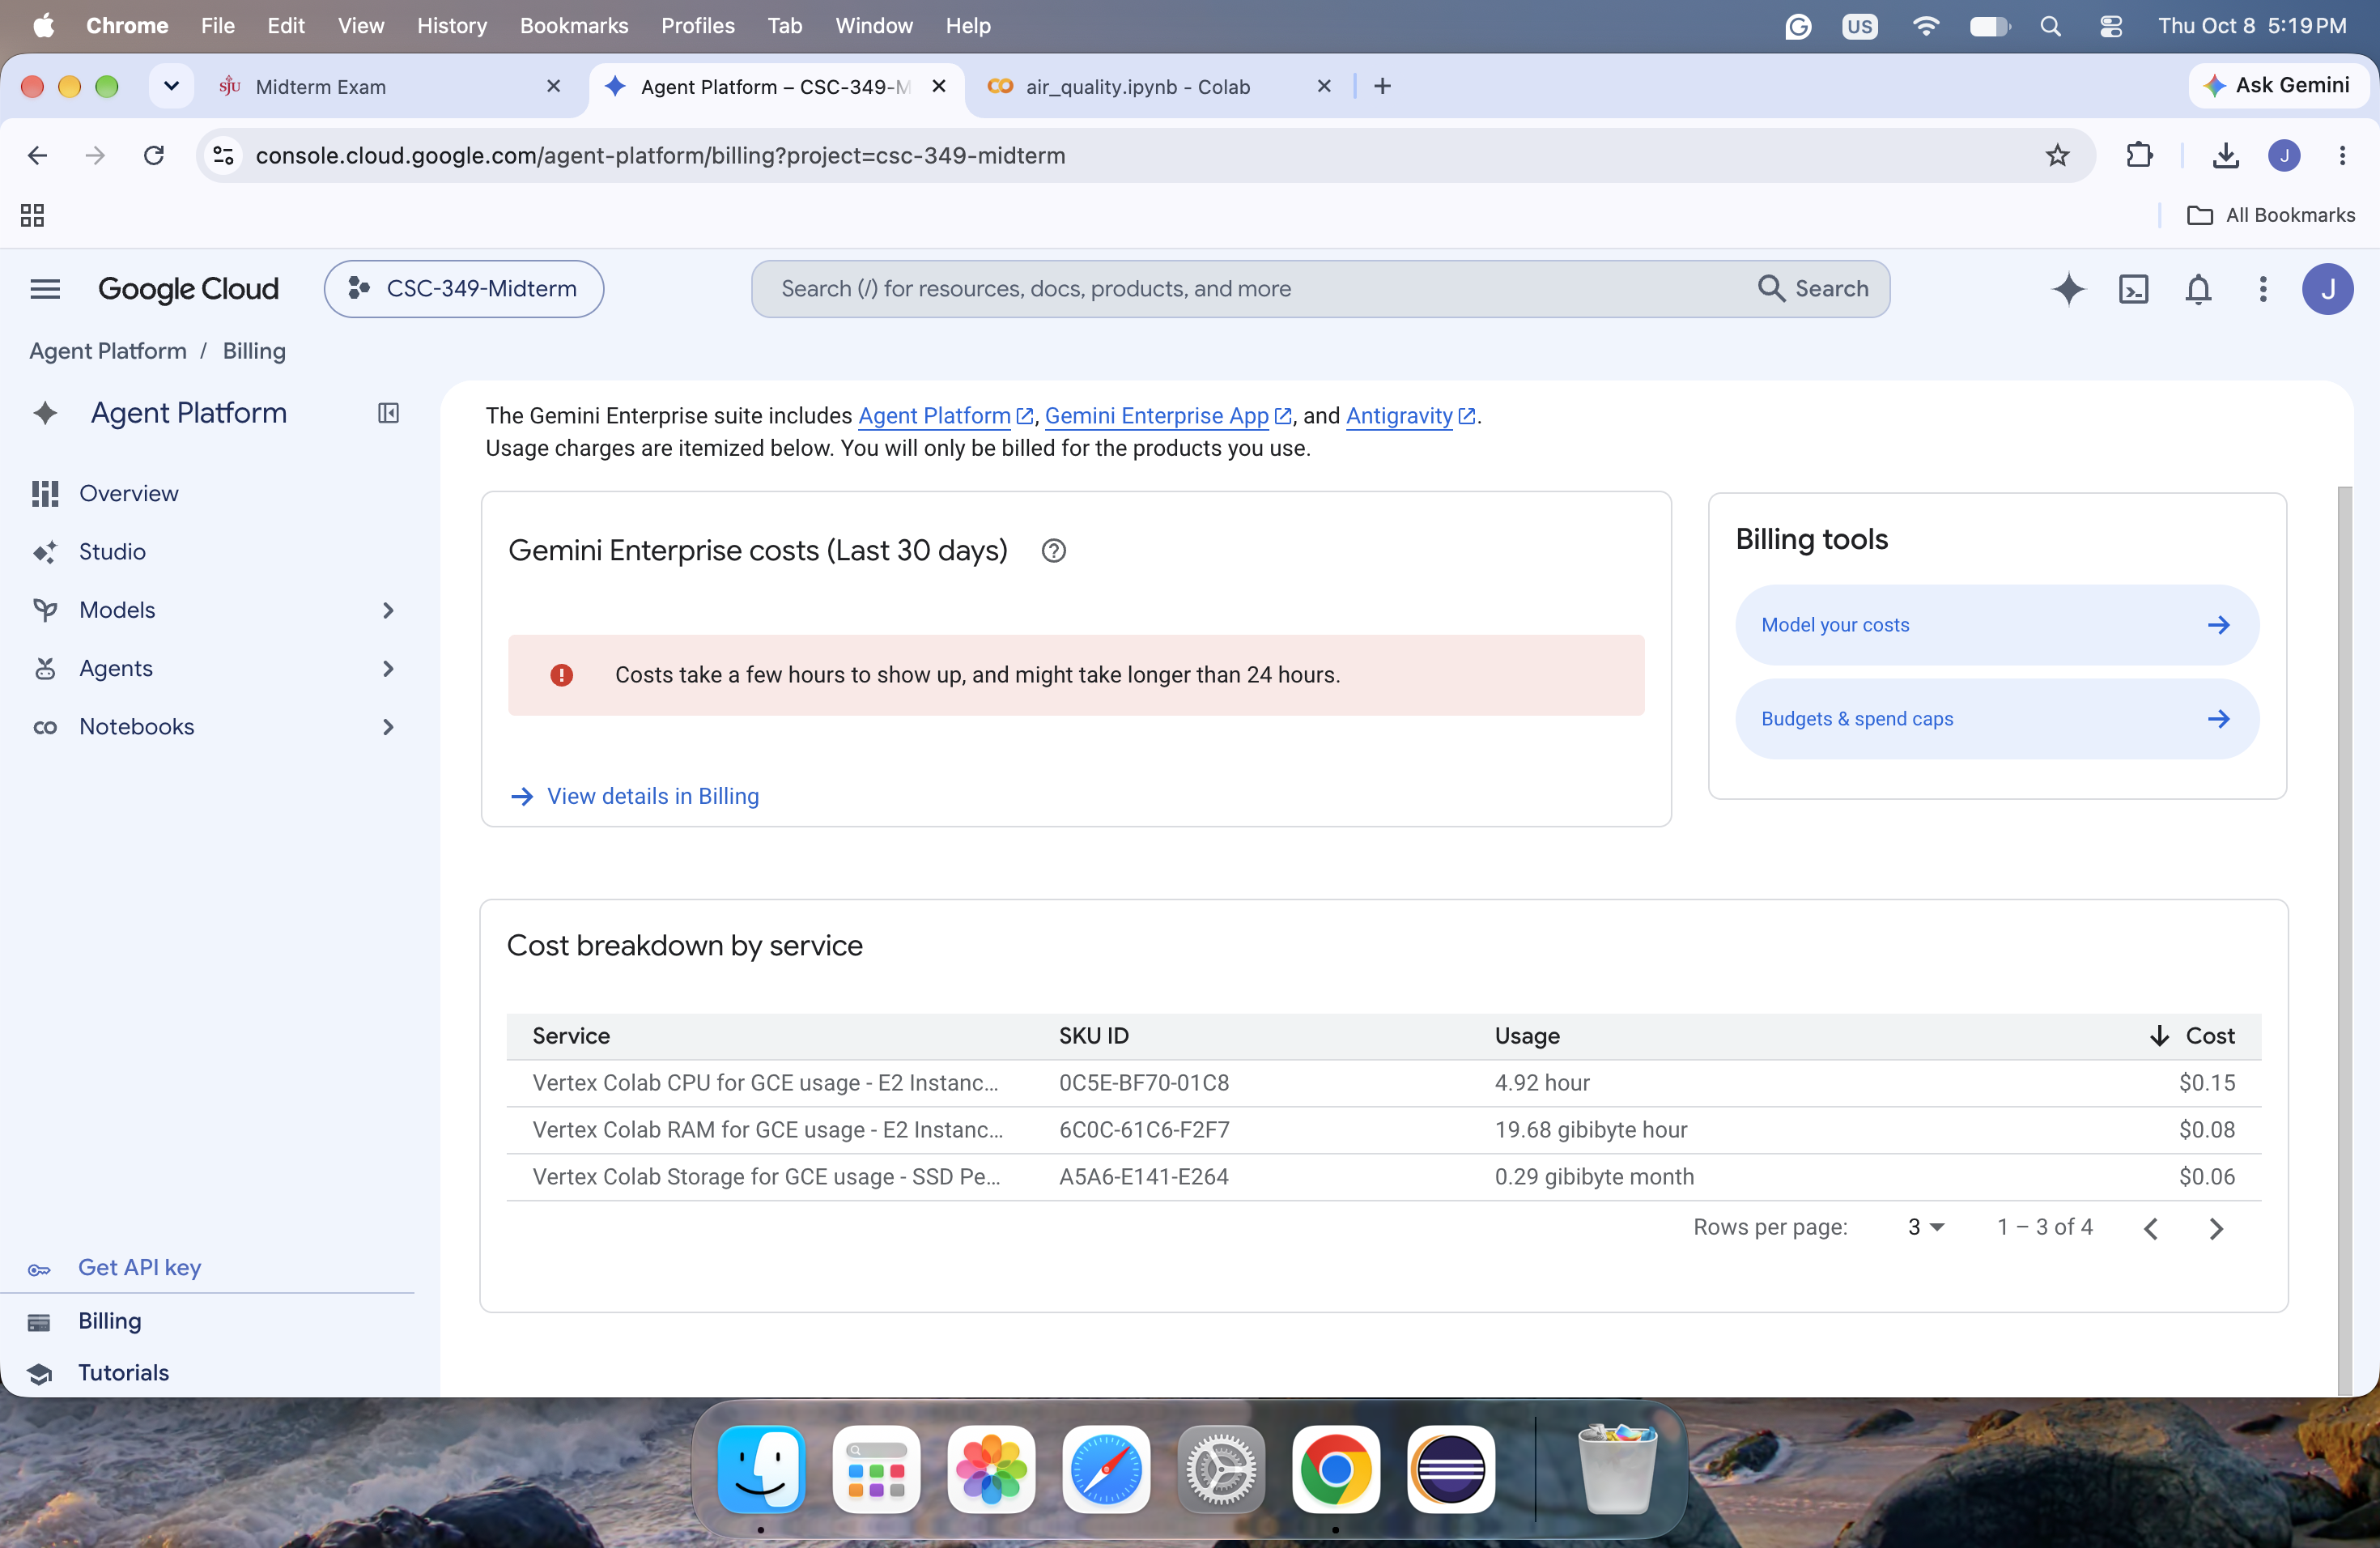

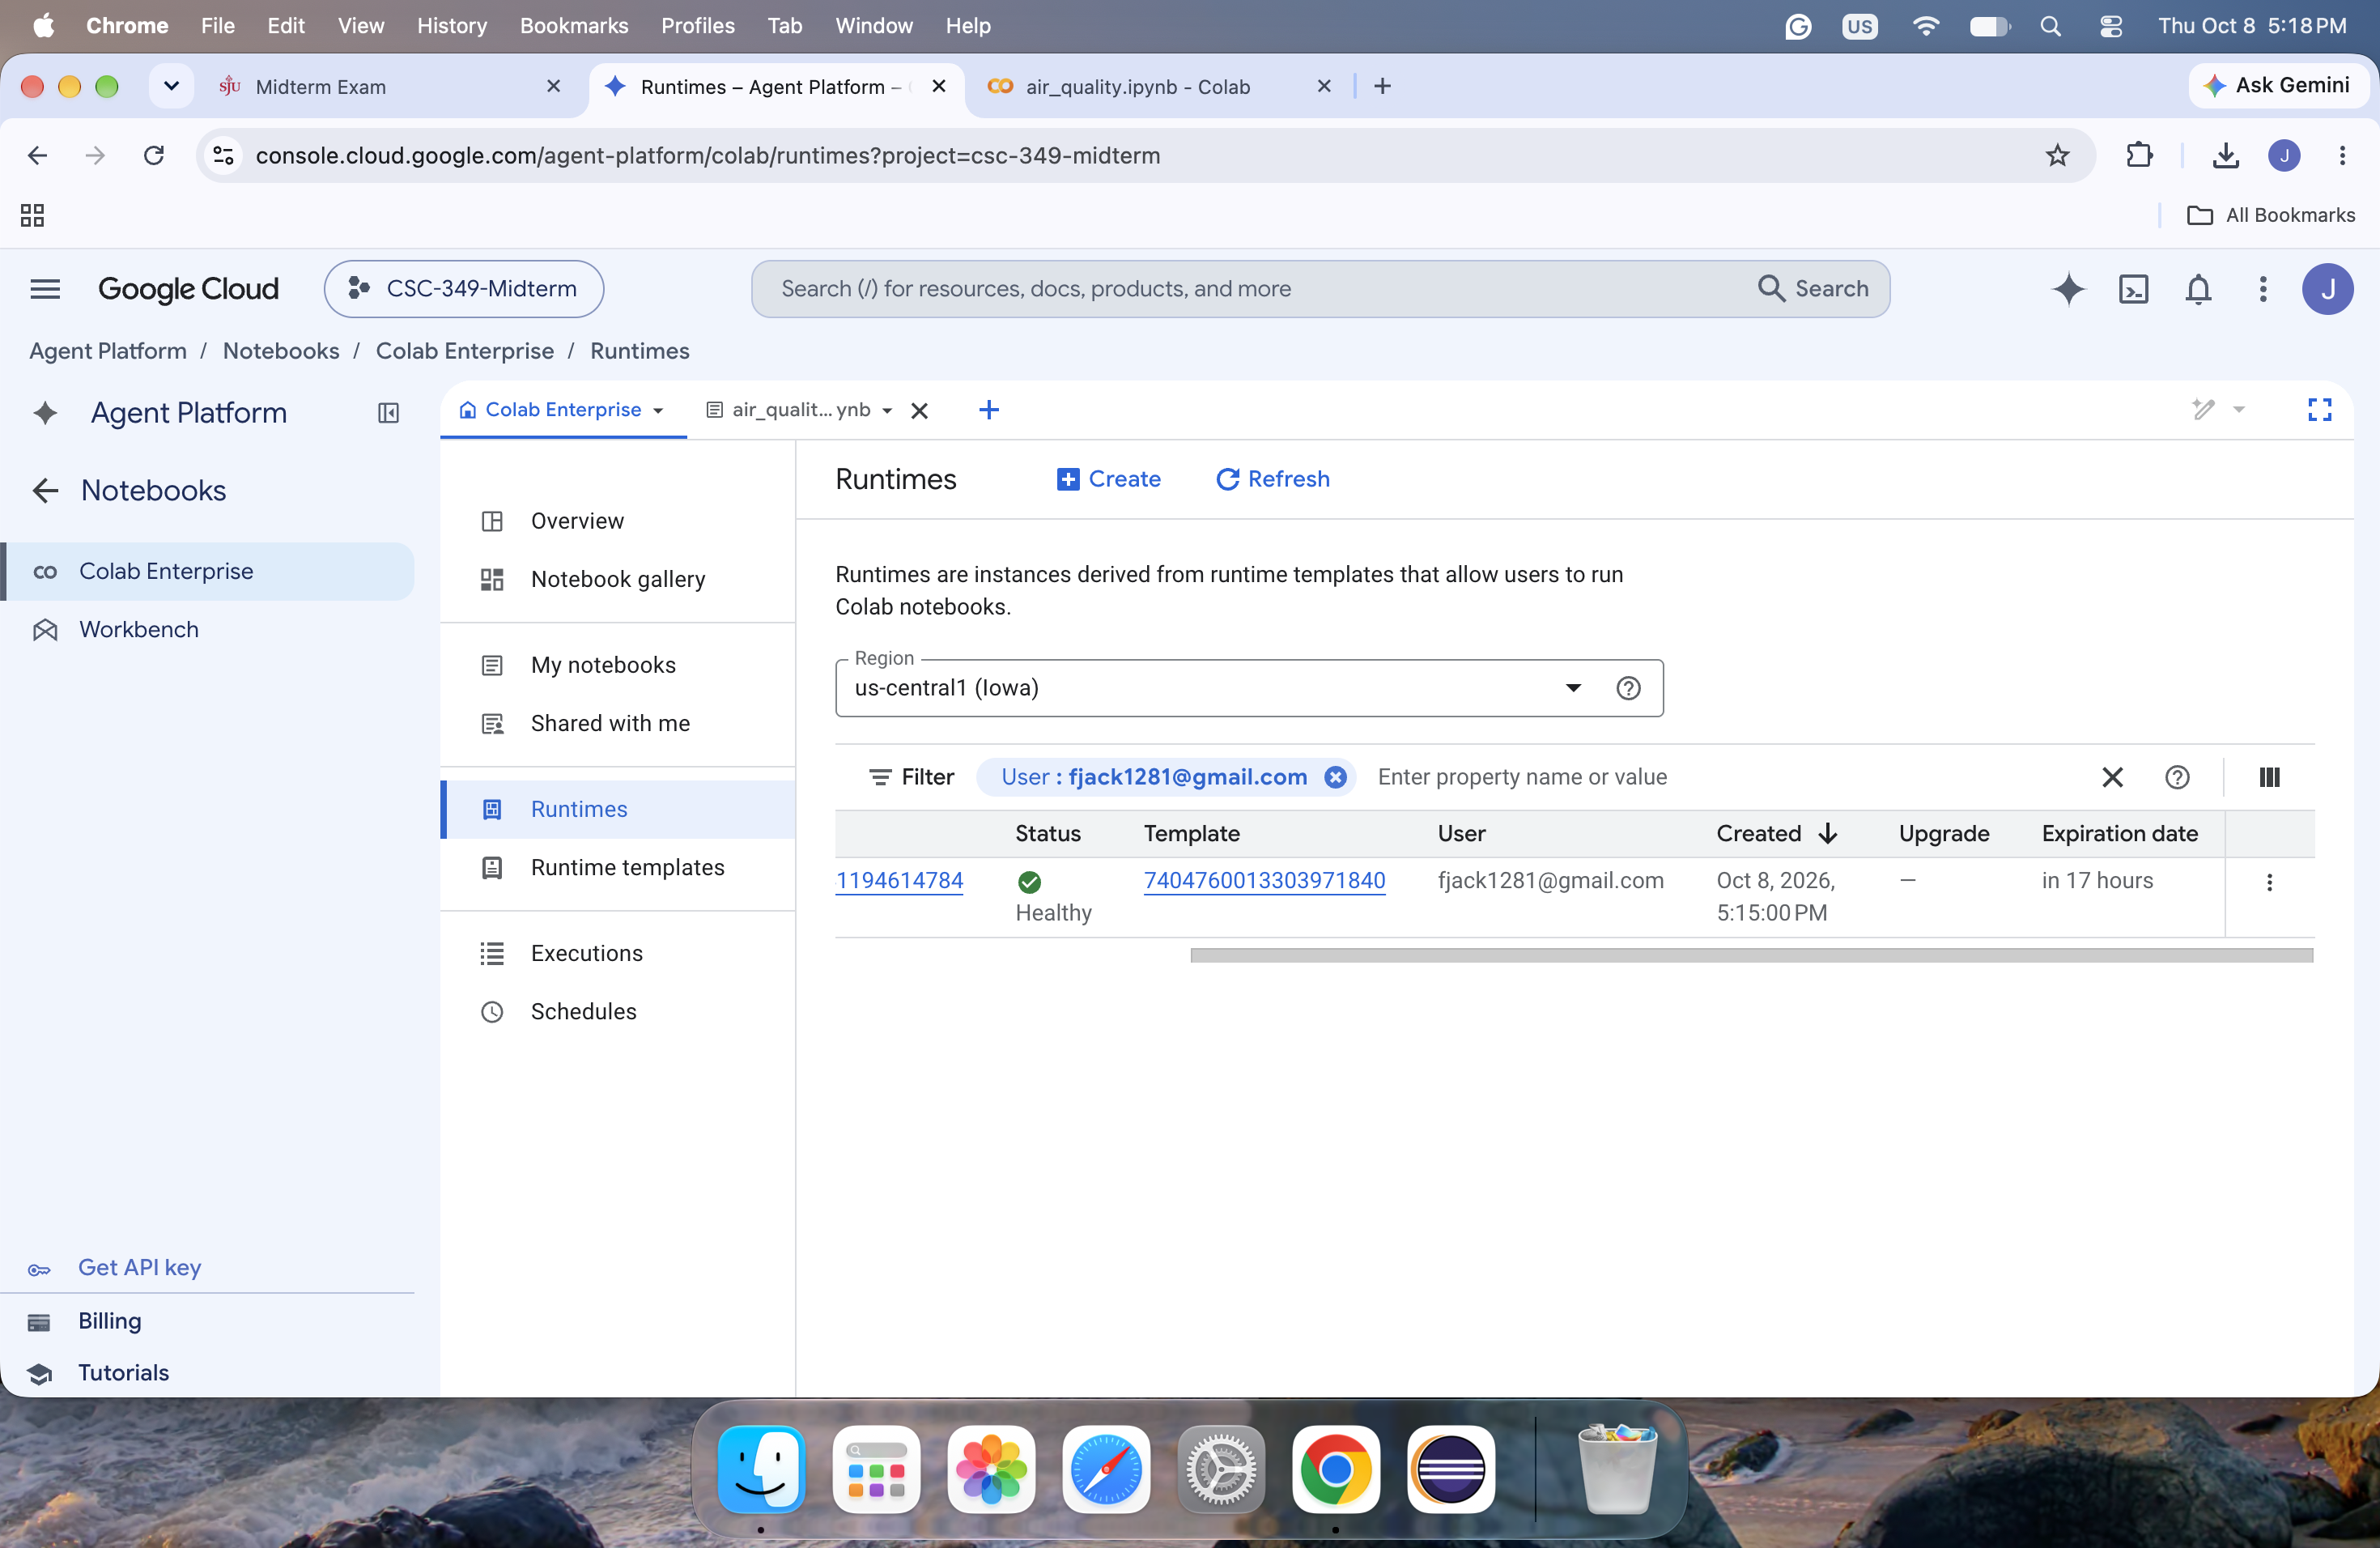

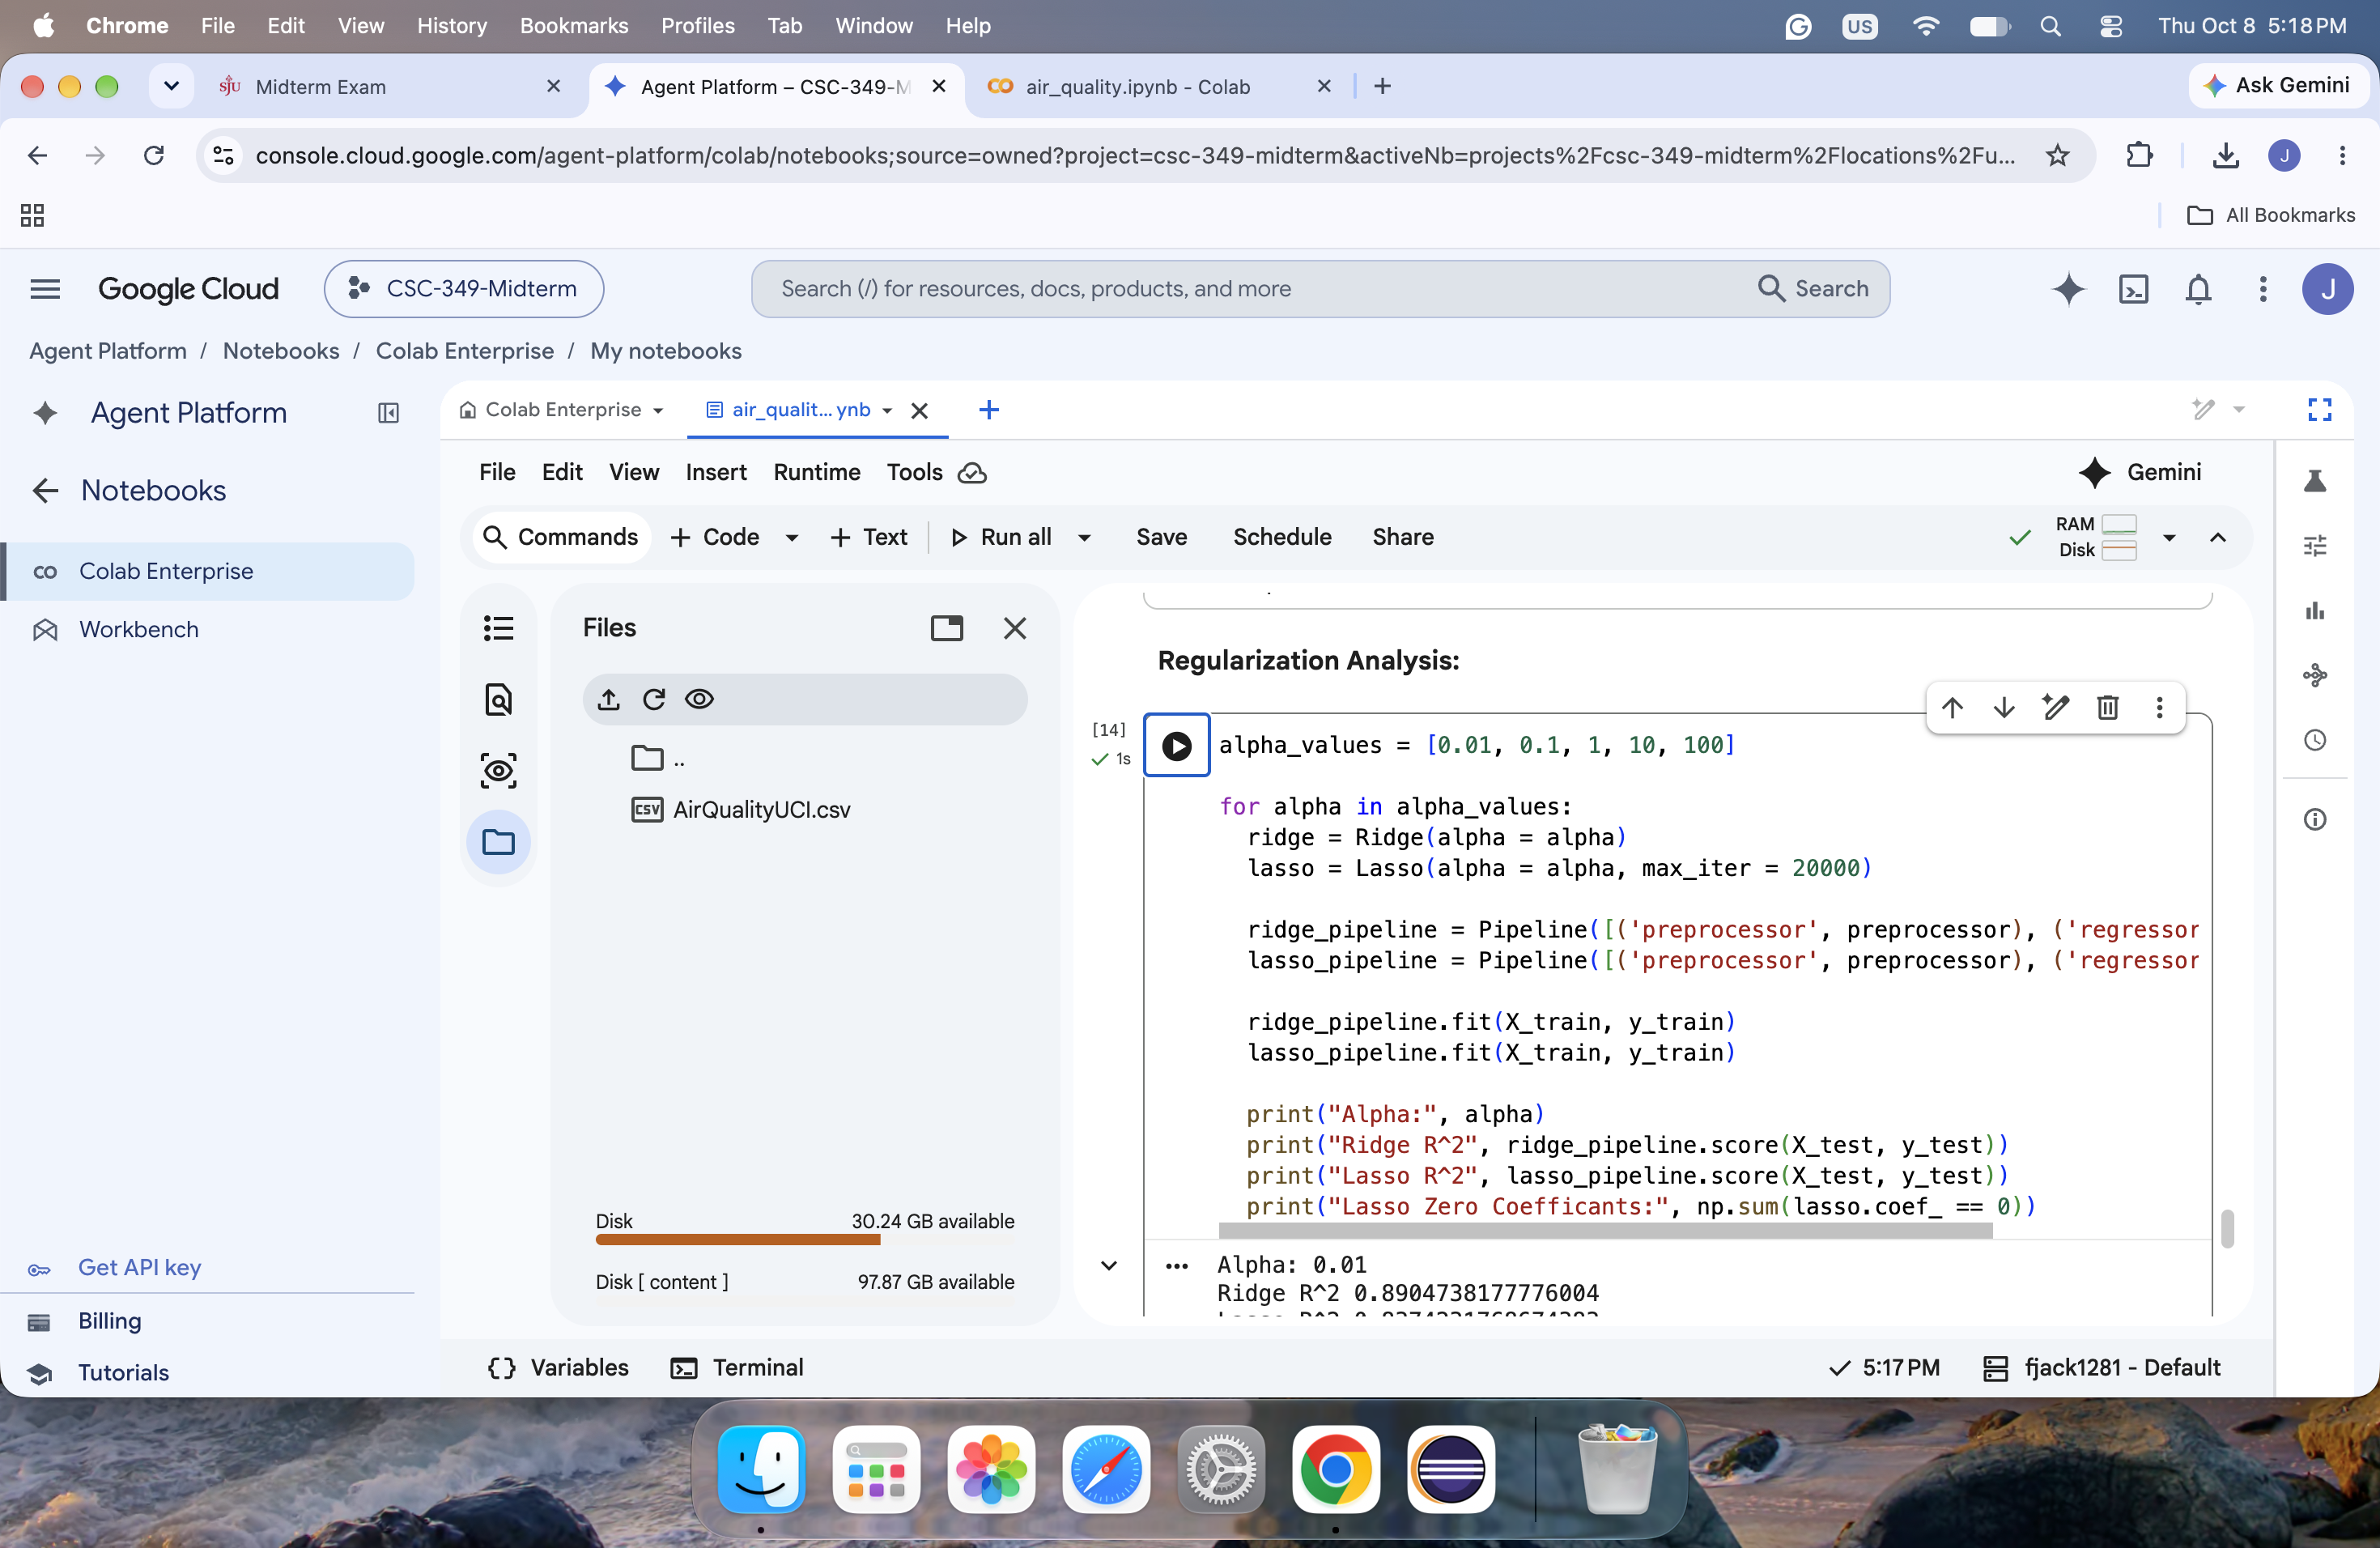